In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import xgboost as xgb
from sklearn import linear_model
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from keras import layers, models


/home/malo/miniconda3/envs/qrt_env/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
2025-10-08 00:35:22.765182: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-08 00:35:22.794281: I tensorflow/core/platform/cpu_feature_guard.cc:210] This

In [2]:
# ==========================
# GÉNÉRATION DES DATES DE TRAIN/TEST
# ==========================

path = 'data/'

X_train = pd.read_csv(path + 'X_train.csv',index_col='ROW_ID')
y_train = pd.read_csv(path + 'y_train.csv',index_col='ROW_ID')

def FAR(row):
    ret = row[RET_features].values
    vol = row[SIGNED_VOLUME_features].values
    return np.sum(ret * vol) / np.sum(np.abs(vol))

RET_features = [f'RET_{i}' for i in range(1,20)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,20)]
TURNOVER_features = ['AVG_DAILY_TURNOVER']
for i in [3,5,10,15,20]:
    X_train[ f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(1)
    X_train[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')
    
#X_train['FAR'] = X_train.apply(FAR, axis=1)
features = RET_features + SIGNED_VOLUME_features + TURNOVER_features + ['FAR']
features = features + [ f'AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]

In [3]:
x_clean = X_train[RET_features+SIGNED_VOLUME_features].values.reshape(-1,65,2, 19)

mean = x_clean.mean(axis=-1, keepdims=True)
std = x_clean.std(axis=-1, keepdims=True) + 1e-8
x_clean = (x_clean - mean) / std

x_noisy = x_clean + np.random.normal(0, 1, x_clean.shape)

In [4]:
print("Shape:", x_noisy.shape)

Shape: (2773, 65, 2, 19)


In [6]:
# ============================
# 2️⃣ Construire l’autoencodeur
# ============================

def build_autoencoder(input_shape, choice='Dense'):
    #input_shape = (n_allocations, n_features, n_time)
    
    if choice == 'Dense':
        inp = layers.Input(shape=input_shape)

        # normaliser 
        # x = layers.LayerNormalization(axis=[-1, -2])(inp)

        # Encode chaque allocation individuellement
        x = layers.TimeDistributed(layers.Flatten())(inp)  # shape: (65, 38)
        x = layers.TimeDistributed(layers.Dense(64, activation='relu'))(x)
        encoded = layers.TimeDistributed(layers.Dense(32, activation='relu'))(x)  # compression

        # Decoder
        x = layers.TimeDistributed(layers.Dense(64, activation='relu'))(encoded)
        x = layers.TimeDistributed(layers.Dense(38, activation='sigmoid'))(x)
        decoded = layers.TimeDistributed(layers.Reshape((input_shape[1],input_shape[2])))(x)

        autoencoder = models.Model(inp, decoded)
        autoencoder.compile(optimizer='adam', loss='mse')

    elif choice == 'LSTM':
         
        n_alloc = 65
        n_features = 1
        n_time = 19
        mid_time = 8
        latent_time = 4

        input_shape = (n_alloc, n_features, n_time)
        inp = layers.Input(shape=input_shape)  # (65,2,19)

        x = layers.LayerNormalization(axis=[-1, -2])(inp) 

        x = layers.Permute((1, 3, 2))(x)
        # encodeur
        x = layers.TimeDistributed(layers.GRU(mid_time, return_sequences=True))(x) 
        x = layers.TimeDistributed(layers.GRU(latent_time, return_sequences=False))(x) 
        encoded = layers.TimeDistributed(layers.Dense(latent_time, activation=None))(x)

        # décodeur
        x = layers.TimeDistributed(layers.RepeatVector(n_time))(encoded)  # -> (batch, n_alloc, n_time, latent_time)
        x = layers.TimeDistributed(layers.GRU(mid_time, return_sequences=True))(x)  # -> (batch, n_alloc, n_time, mid_time)
        x = layers.TimeDistributed(layers.GRU(n_features, return_sequences=True))(x)  # -> (batch, n_alloc, n_time, n_features)

        decoded = layers.Permute((1, 3, 2))(x) 

    
    else : # choice == 'Conv1D'

        inp = layers.Input(shape=input_shape)

        # normaliser
        # x = layers.LayerNormalization(axis=[-1, -2])(inp)

        # On permute pour traiter la dimension temporelle (Conv1D sur les 20 points)
        x = layers.Permute((1,3,2))(inp)  # (65, 19, 2)

        # encodeur
        x = layers.TimeDistributed(layers.Conv1D(16, 3, activation='relu', padding='same'))(x)
        x = layers.TimeDistributed(layers.Conv1D(8, 3, activation='relu', padding='same'))(x)
        x = layers.TimeDistributed(layers.MaxPooling1D(2, padding='same'))(x)  # downsample

        # decodeur
        x = layers.TimeDistributed(layers.Conv1D(8, 3, activation='relu', padding='same'))(x)
        x = layers.TimeDistributed(layers.UpSampling1D(2))(x)
        x = layers.TimeDistributed(layers.Cropping1D(cropping=(0,1)))(x)
        x = layers.TimeDistributed(layers.Conv1D(2, 3, activation='sigmoid', padding='same'))(x)
        decoded = layers.Permute((1,3,2))(x)

    autoencoder = models.Model(inp, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    autoencoder.summary()
    return autoencoder



choice = 'LSTM'  # ou 'Dense' ou 'LSTM'


autoencoder = build_autoencoder(
    input_shape=(x_clean.shape[1], x_clean.shape[2], x_clean.shape[3]),
    choice=choice  # ou 'Conv1D'
)

# ============================
# 3️⃣ Entraînement
# ============================

train_size = int(0.7 * x_clean.shape[0])
valid_size = int(0.9 * x_clean.shape[0])
X_train_auto, X_val_auto = x_noisy[:train_size], x_noisy[train_size:valid_size]
Y_train_auto, Y_val_auto = x_clean[:train_size], x_clean[train_size:valid_size]

if choice == 'LSTM':
    # Reshape pour LSTM
    ret_auto = autoencoder.fit(
        X_train_auto[:,:,0,:].reshape(-1,65,1,19), 
        Y_train_auto[:,:,0,:].reshape(-1,65,1,19),
        validation_data=(X_val_auto[:,:,0,:].reshape(-1,65,1,19), Y_val_auto[:,:,0,:].reshape(-1,65,1,19)),
        epochs=30,
        batch_size=32,
        shuffle=False  # très important !
    )
    vol_auto = autoencoder.fit(
        X_train_auto[:,:,1,:].reshape(-1,65,1,19), Y_train_auto[:,:,1,:].reshape(-1,65,1,19),
        validation_data=(X_val_auto[:,:,1,:].reshape(-1,65,1,19), Y_val_auto[:,:,1,:].reshape(-1,65,1,19)),
        epochs=30,
        batch_size=32,
        shuffle=False  # très important !
    )


else :

    history = autoencoder.fit(
        X_train_auto, Y_train_auto,
        validation_data=(X_val_auto, Y_val_auto),
        epochs=30,
        batch_size=32,
        shuffle=False  # très important !
    )


# ============================
# 4️⃣ Évaluation visuelle
# ============================

# Prendre un échantillon
X_test_auto = x_noisy[valid_size:]
Y_test_auto = x_clean[valid_size:]


if choice == 'LSTM':
    
    ret_reconstructed = autoencoder.predict(X_test_auto[:,:,0,:].reshape(-1,65,1,19))
    vol_reconstructed = autoencoder.predict(X_test_auto[:,:,1,:].reshape(-1,65,1,19))

    mse_ret = np.mean((Y_test_auto[:,:,0,:].reshape(-1,65,1,19) - ret_reconstructed)**2)
    mse_vol = np.mean((Y_test_auto[:,:,1,:].reshape(-1,65,1,19) - vol_reconstructed)**2)
    print(f"MSE RET: {mse_ret:.6f}, MSE VOL: {mse_vol:.6f}")
    reconstructed = np.concatenate([ret_reconstructed, vol_reconstructed], axis=2)
else :
    reconstructed = autoencoder.predict(X_test_auto)


# ============================
# 5️⃣ Évaluer la qualité
# ============================
mse = np.mean((Y_test_auto - reconstructed)**2)
print(f"Erreur quadratique moyenne (MSE) sur l’échantillon : {mse:.6f}")


2025-10-08 00:35:24.283115: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-10-08 00:35:24.283411: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 65, 1, 19)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 65, 1, 19)      │            38 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 65, 19, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 65, 19, 8)      │           264 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 65, 4)          │           168 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 65, 4)          │            20 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 65, 19, 4)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 65, 19, 8)      │           336 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 65, 19, 1)      │            33 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_1 (Permute)             │ (None, 65, 1, 19)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 859 (3.36 KB)

 Trainable params: 859 (3.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


2025-10-08 00:37:53.708718: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


61/61 ━━━━━━━━━━━━━━━━━━━━ 213s 982ms/step - loss: 0.9988 - val_loss: 0.9964
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 39s 632ms/step - loss: 0.9867 - val_loss: 0.9744
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 38s 616ms/step - loss: 0.9713 - val_loss: 0.9680
Epoch 4/30
18/61 ━━━━━━━━━━━━━━━━━━━━ 25s 600ms/step - loss: 0.9693

KeyboardInterrupt: 

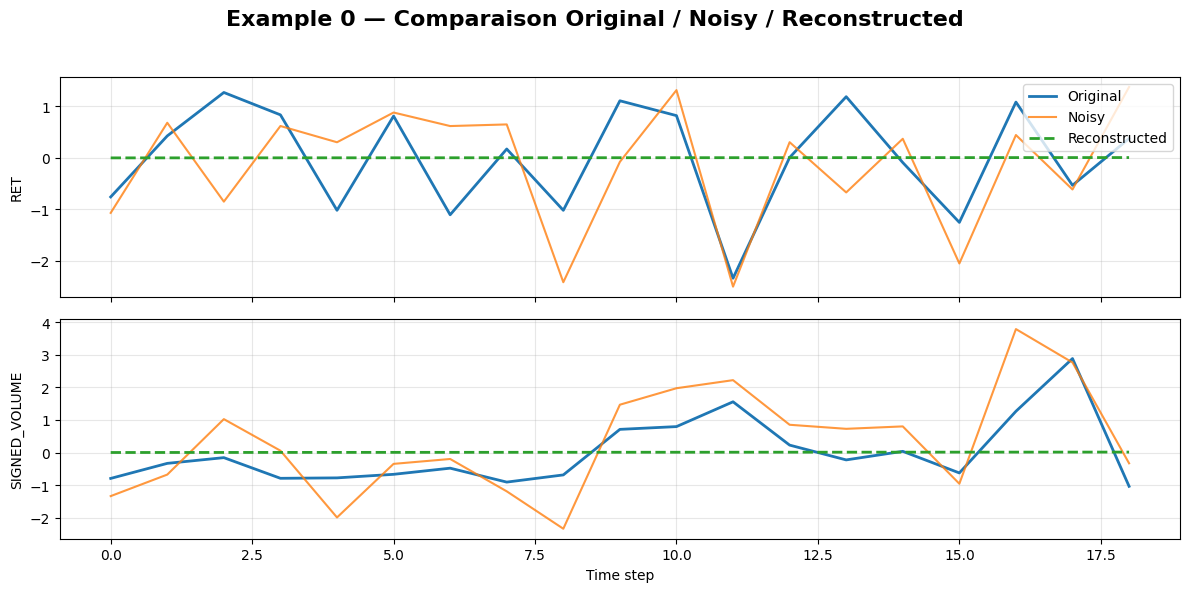

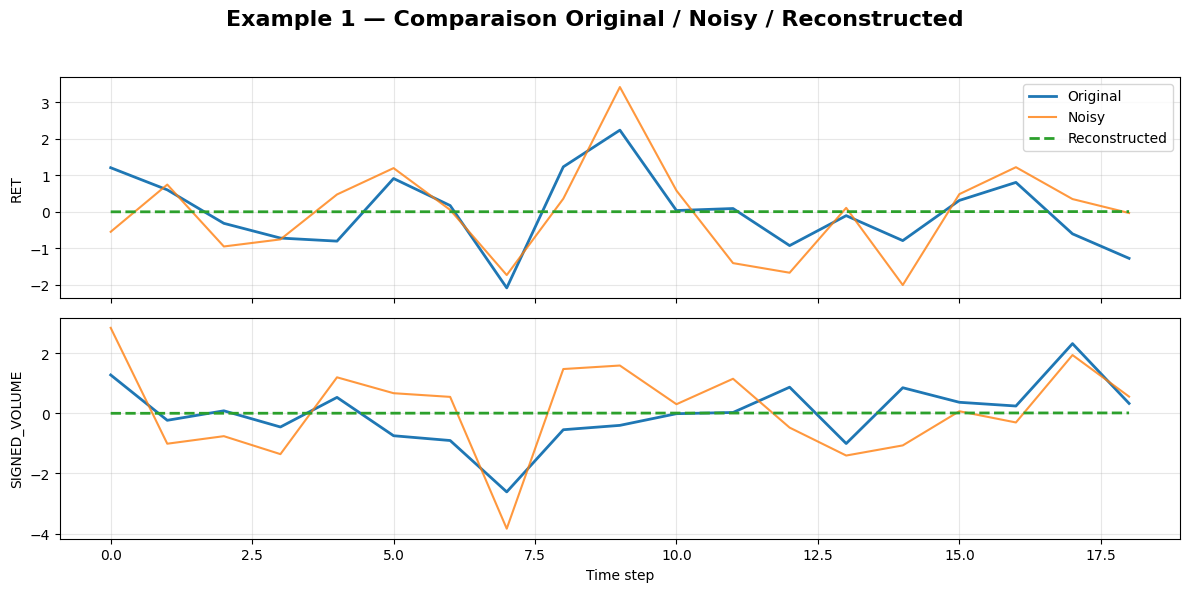

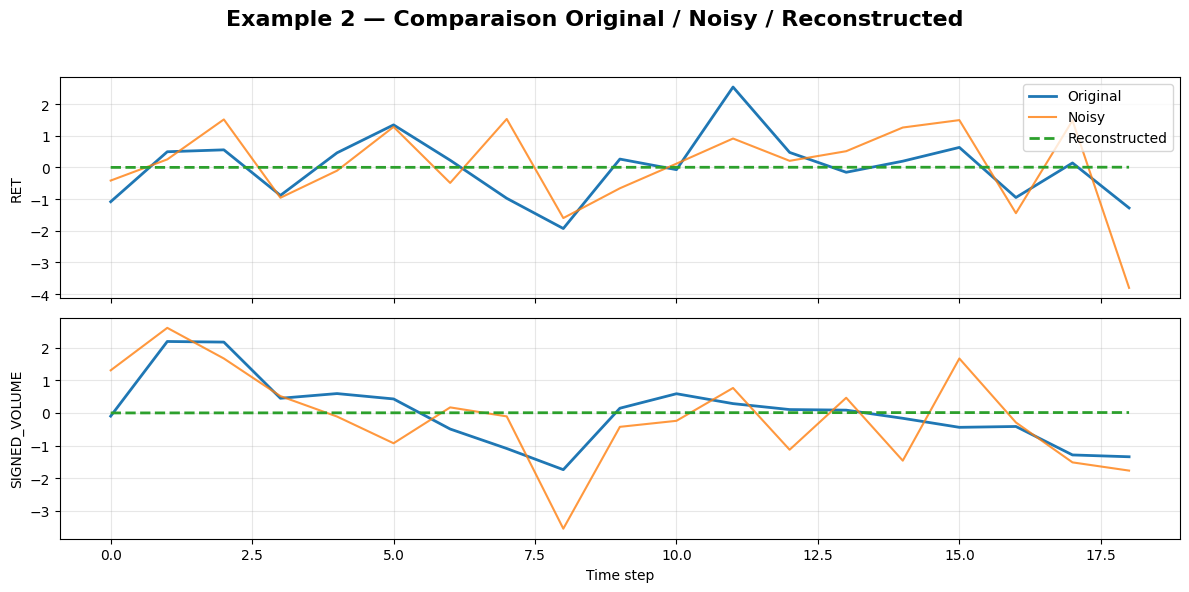

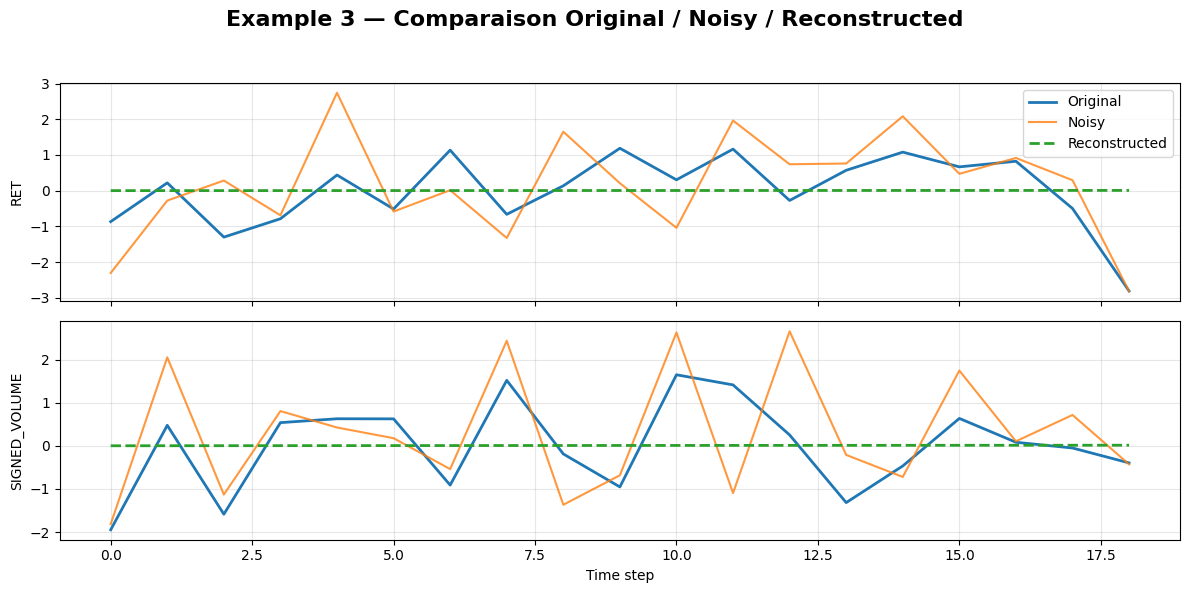

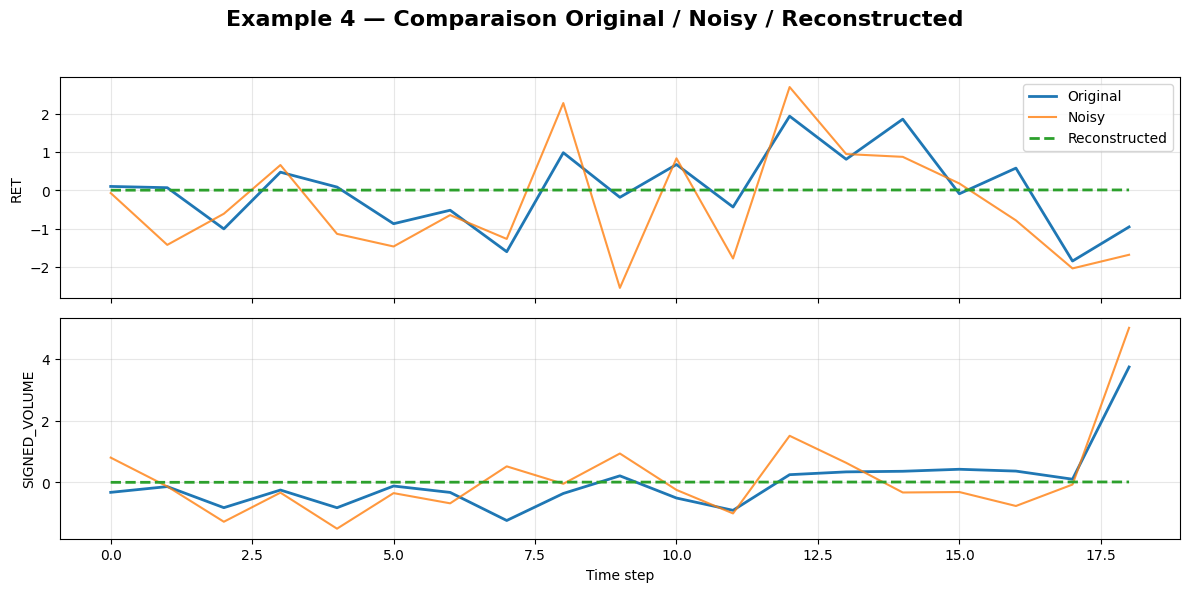

In [95]:
import matplotlib.pyplot as plt
import numpy as np

n_examples = 5  # nombre d'exemples à visualiser
features = ['RET', 'SIGNED_VOLUME']
n_features = 2
time_steps = Y_test_auto.shape[-1]

for i in range(n_examples):
    fig, axes = plt.subplots(n_features, 1, figsize=(12, 6), sharex=True)
    fig.suptitle(f"Example {i} — Comparaison Original / Noisy / Reconstructed", fontsize=16, fontweight='bold')
    
    t = np.arange(time_steps)
    
    for f in range(n_features):
        ax = axes[f]
        
        # Extraire les trois séries pour cette feature
        orig = Y_test_auto[i, 0, f, :]
        noisy = X_test_auto[i, 0, f, :]
        recon = reconstructed[i, 0, f, :]
        
        # Tracer les trois courbes
        ax.plot(t, orig, label='Original', color='tab:blue', linewidth=2)
        ax.plot(t, noisy, label='Noisy', color='tab:orange', linewidth=1.5, alpha=0.8)
        ax.plot(t, recon, label='Reconstructed', color='tab:green', linewidth=2, linestyle='--')
        
        ax.set_ylabel(f"{features[f]}")
        ax.grid(True, alpha=0.3)
        if f == 0:
            ax.legend(loc='upper right', fontsize=10)
    
    axes[-1].set_xlabel("Time step")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
from keras import layers, models

# ----------------------
# paramètres
# ----------------------
n_alloc = 65
n_features = 1
n_time = 19
mid_time = 8
latent_time = 4

# ----------------------
# modèle
# ----------------------
input_shape = (n_alloc, n_features, n_time)
inp = layers.Input(shape=input_shape) 

x = layers.LayerNormalization(axis=[-1, -2])(inp) 

x = layers.Permute((1, 3, 2))(x)
# encodeur
x = layers.TimeDistributed(layers.GRU(mid_time, return_sequences=True))(x) 
x = layers.TimeDistributed(layers.GRU(latent_time, return_sequences=False))(x) 
encoded = layers.TimeDistributed(layers.Dense(latent_time, activation=None))(x)

# décodeur
x = layers.TimeDistributed(layers.RepeatVector(n_time))(encoded)  # -> (batch, n_alloc, n_time, latent_time)
x = layers.TimeDistributed(layers.GRU(mid_time, return_sequences=True))(x)  # -> (batch, n_alloc, n_time, mid_time)
x = layers.TimeDistributed(layers.GRU(n_features, return_sequences=True))(x)  # -> (batch, n_alloc, n_time, n_features)

out = layers.Permute((1, 3, 2))(x) 

autoencoder = models.Model(inp, out)
autoencoder.compile(optimizer='adam', loss='mse')


# affichage
print("Autoencoder summary:")
autoencoder.summary()


Autoencoder summary:


Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_31 (InputLayer)     │ (None, 65, 1, 19)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_29          │ (None, 65, 1, 19)      │            38 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_38 (Permute)            │ (None, 65, 19, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_194            │ (None, 65, 19, 8)      │           264 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_195            │ (None, 65, 4)          │           168 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_196            │ (None, 65, 4)          │            20 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_197            │ (None, 65, 19, 4)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_198            │ (None, 65, 19, 8)      │           336 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_199            │ (None, 65, 19, 1)      │            33 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_39 (Permute)            │ (None, 65, 1, 19)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 859 (3.36 KB)

 Trainable params: 859 (3.36 KB)

 Non-trainable params: 0 (0.00 B)